# 05 - Evaluation
**CRISP-DM phase:** Evaluation

This notebook judges the selected models against the success criteria set in notebook 01:
1. Every model beats its baseline on **untouched test data** (CRSS 2024; complaints 2024-2026).
2. No material **overfitting** (train vs validation gaps, learning curves) and acceptable **stability over time** (validation vs test).
3. Results are **explainable**: what drives each prediction.
4. Each research question RQ1-RQ5 is answered.

## 5.0 Setup

In [1]:
from pathlib import Path
import json, sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from project_paths import EVALUATION_DIR, FIGURE_DIR, TABLE_DIR

pd.set_option("display.max_columns", 40, "display.width", 220, "display.precision", 3)
load = lambda name: pd.read_csv(EVALUATION_DIR / name)
results = {t: load(f"crss_{t}_model_comparison.csv") for t in ("y_injury", "y_serious")}
results |= {t: load(f"text_{t}_model_comparison.csv") for t in ("U1", "U2")}
selected = {t: r[r.selected].iloc[0] for t, r in results.items()}

## 5.1 Headline results on untouched test data
The test period was never used for training, tuning, threshold choice or model selection.

In [2]:
dummy = {t: r[r.model == "Dummy (prior)"].iloc[0] for t, r in results.items()}
headline = pd.DataFrame([
    {"model": "S1 injury crash", "selected": selected["y_injury"].model, "metric": "PR-AUC",
     "baseline": dummy["y_injury"].test_pr_auc, "test": selected["y_injury"].test_pr_auc, "test ROC-AUC": selected["y_injury"].test_roc_auc},
    {"model": "S2 serious/fatal crash", "selected": selected["y_serious"].model, "metric": "PR-AUC",
     "baseline": dummy["y_serious"].test_pr_auc, "test": selected["y_serious"].test_pr_auc, "test ROC-AUC": selected["y_serious"].test_roc_auc},
    {"model": "U1 component routing", "selected": selected["U1"].model, "metric": "macro PR-AUC",
     "baseline": dummy["U1"].validation_pr_auc, "test": selected["U1"].test_macro_pr_auc, "test ROC-AUC": None},
    {"model": "U2 serious-incident flag", "selected": selected["U2"].model, "metric": "PR-AUC",
     "baseline": dummy["U2"].validation_pr_auc, "test": selected["U2"].test_pr_auc, "test ROC-AUC": selected["U2"].test_roc_auc},
])
headline

,model,selected,metric,baseline,test,test ROC-AUC
0,S1 injury crash,Gradient Boosting,PR-AUC,0.513,0.918,0.906
1,S2 serious/fatal crash,Gradient Boosting,PR-AUC,0.130,0.642,0.902
2,U1 component routing,Linear SVM,macro PR-AUC,0.071,0.725,NaN
3,U2 serious-incident flag,Linear SVM,PR-AUC,0.064,0.858,0.965


**Interpretation.** PR-AUC is the headline metric because it focuses on the class we care about (injury, serious harm, a given component), and its no-skill baseline equals that class's share. All four models far exceed their baselines on data from a later period than they were trained on. *(The U1 baseline shown is the average validation share of a component group.)*

## 5.2 Overfitting check: training vs validation
A model that memorises its training data scores much higher on training than on validation. The table shows the gap for every candidate.

In [3]:
gaps = []
for t, r in results.items():
    r = r[r.model != "Dummy (prior)"]
    metric = "macro_f1" if t == "U1" else ("pr_auc" if t == "U2" else "roc_auc")
    for _, x in r.iterrows():
        gaps.append({"task": t, "feature_set": x.get("feature_set", "text"), "class_weight": x.get("class_weight", "-"),
                     "model": x.model, "metric": metric, "train": x[f"train_{metric}"],
                     "validation": x[f"validation_{metric}"], "gap": x[f"train_{metric}"] - x[f"validation_{metric}"],
                     "selected": x.selected})
gaps = pd.DataFrame(gaps)
gaps.pivot_table(index=["task", "model"], values="gap", aggfunc="max").round(3)

gap
task      model                        
U1        Complement Naive Bayes  0.077
          Linear SVM              0.066
          Logistic Regression     0.124
U2        Complement Naive Bayes  0.053
          Linear SVM              0.076
          Logistic Regression     0.102
y_injury  Decision Tree           0.009
          Gradient Boosting       0.022
          Logistic Regression    -0.004
          Random Forest           0.081
y_serious Decision Tree           0.030
          Gradient Boosting       0.050
          Logistic Regression     0.029
          Random Forest           0.111

**Interpretation.** Random Forest shows by far the largest gaps (0.08 for S1, 0.11 for S2): its deep trees memorise individual training crashes, so it was not selected despite good validation scores. Logistic Regression and the Decision Tree have small gaps (at most about 0.03). The selected Gradient Boosting models also stay small (0.022 for S1 and 0.029 for S2 at the selected settings; the table shows the largest gap across settings), an acceptable price for the best validation scores. For the text models, Logistic Regression fits the training text more tightly than Linear SVM, which is one reason the SVM is selected.

### Learning curves
Each selected model is refitted on growing fractions of the training data. Overfitting appears as a training curve far above a flat validation curve; healthy learning appears as the two curves converging, with validation still rising as data is added.

crss_y_injury_diagnostics.png


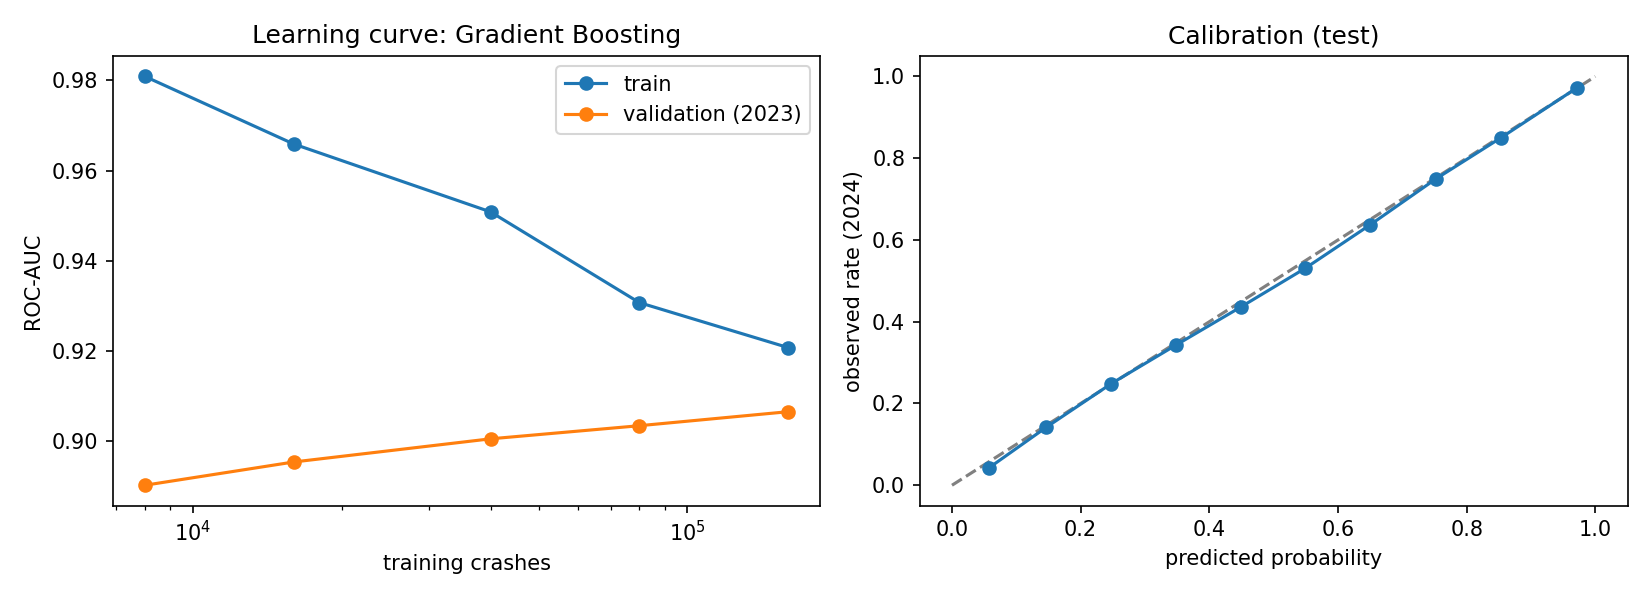

crss_y_serious_diagnostics.png


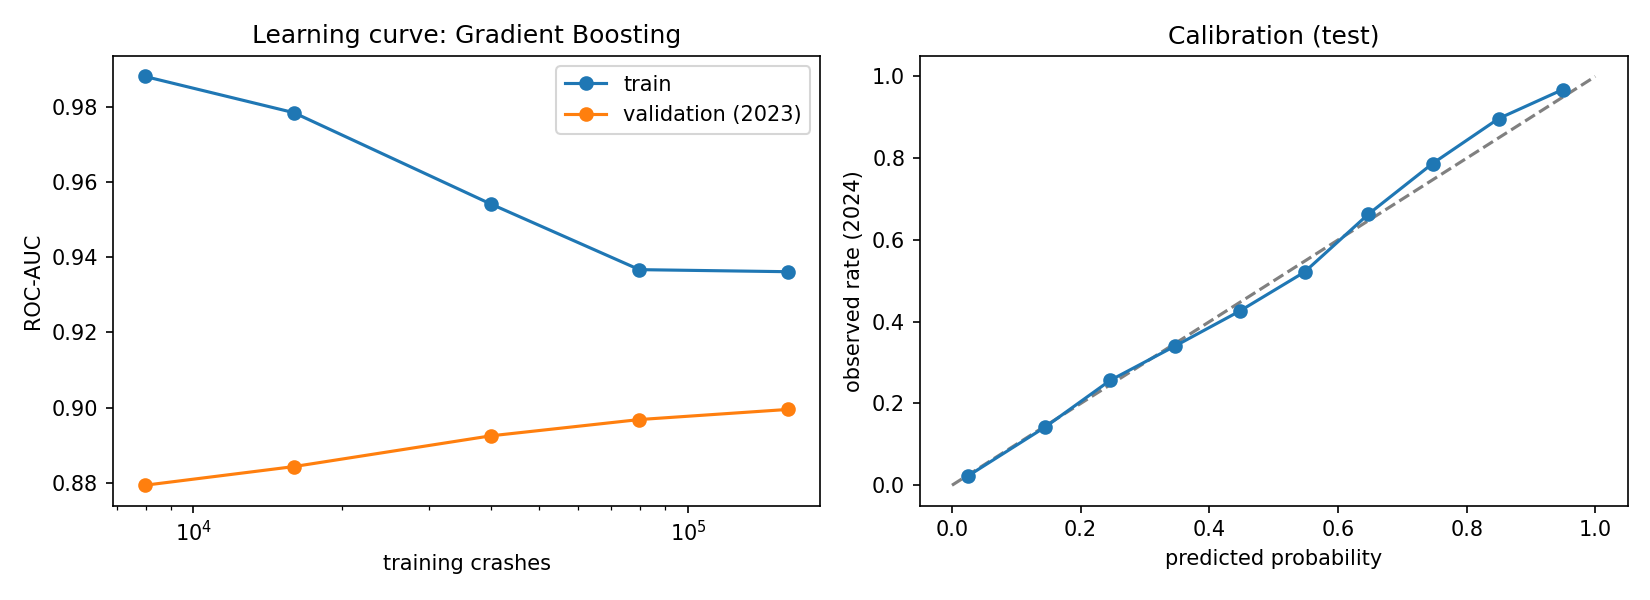

text_U2_learning_curve.png


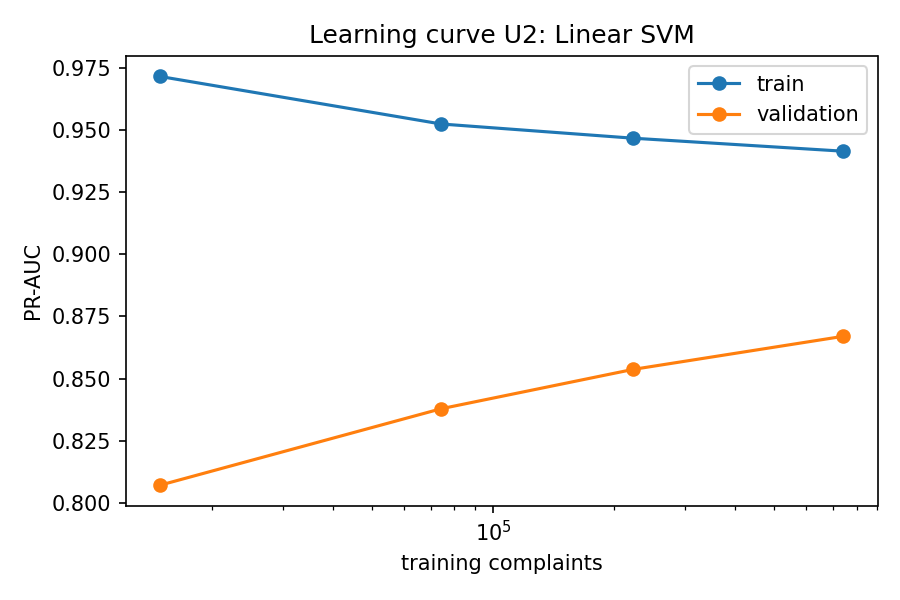

text_U1_learning_curve.png


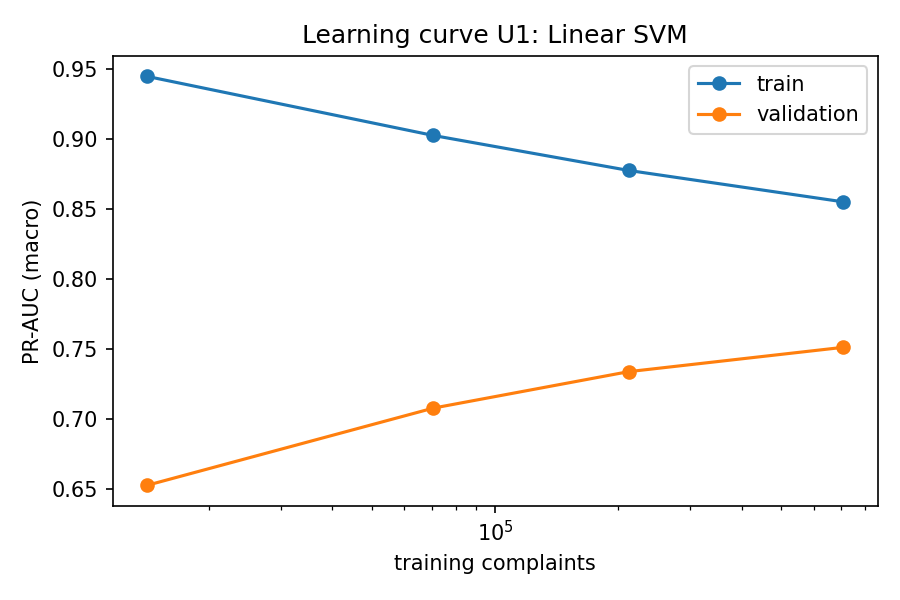

In [4]:
for f in ["crss_y_injury_diagnostics.png", "crss_y_serious_diagnostics.png",
          "text_U2_learning_curve.png", "text_U1_learning_curve.png"]:
    print(f); display(Image(filename=str(EVALUATION_DIR / f), width=760))

In [5]:
curves = {t: load(f"crss_{t}_learning_curve.csv") for t in ("y_injury", "y_serious")}
curves |= {t: load(f"text_{t}_learning_curve.csv") for t in ("U1", "U2")}
for t, c in curves.items():
    c = c.copy(); c.columns = ["train_rows", "train", "validation"]
    c["gap"] = c.train - c.validation
    print(t); display(c.round(3))

y_injury


,train_rows,train,validation,gap
0,7996,0.981,0.890,0.091
1,15992,0.966,0.895,0.070
2,39980,0.951,0.901,0.050
3,79960,0.931,0.903,0.027
4,159920,0.921,0.907,0.014


y_serious


,train_rows,train,validation,gap
0,7975,0.988,0.879,0.109
1,15951,0.979,0.884,0.094
2,39879,0.954,0.892,0.062
3,79758,0.937,0.897,0.040
4,159516,0.936,0.899,0.037


U1


,train_rows,train,validation,gap
0,14127,0.945,0.653,0.292
1,70637,0.903,0.708,0.195
2,211913,0.878,0.734,0.144
3,706377,0.855,0.751,0.104


U2


,train_rows,train,validation,gap
0,14832,0.971,0.807,0.164
1,74162,0.952,0.838,0.114
2,222486,0.947,0.854,0.093
3,741623,0.941,0.867,0.074


**Interpretation.** In every case the gap shrinks and the validation score keeps rising as training data grows: the models are limited by data, not memorising it. This also justifies using the full data volume: performance at the largest training size is the best observed.

## 5.3 Stability over time: validation vs test
Validation and test come from different years. Similar scores mean the model holds up as time moves on; a large drop would signal drift.

In [6]:
stab = []
for t in ("y_injury", "y_serious", "U2"):
    s = selected[t]
    stab.append({"task": t, "model": s.model, "validation ROC-AUC": s.validation_roc_auc, "test ROC-AUC": s.test_roc_auc,
                 "validation PR-AUC": s.validation_pr_auc, "test PR-AUC": s.test_pr_auc})
s = selected["U1"]
stab.append({"task": "U1", "model": s.model, "validation PR-AUC": s.validation_macro_pr_auc, "test PR-AUC": s.test_macro_pr_auc})
pd.DataFrame(stab)

,task,model,validation ROC-AUC,test ROC-AUC,validation PR-AUC,test PR-AUC
0,y_injury,Gradient Boosting,0.906,0.906,0.919,0.918
1,y_serious,Gradient Boosting,0.900,0.902,0.647,0.642
2,U2,Linear SVM,0.965,0.965,0.867,0.858
3,U1,Linear SVM,NaN,NaN,0.751,0.725


**Interpretation.** Crash-model scores are essentially unchanged from 2023 to 2024. The text models drop slightly from 2022-23 to 2024-26, as expected: the complaint mix keeps shifting (notebook 02: driver-assistance and engine complaints rising), which the deployment plan addresses with periodic retraining.

## 5.4 Decisions at the chosen threshold (S1, S2)

In [7]:
for t in ("y_injury", "y_serious"):
    cm = pd.read_csv(EVALUATION_DIR / f"crss_{t}_confusion_test.csv", index_col=0)
    tn, fp, fn, tp = cm.values.ravel()
    print(f"{t}: threshold {selected[t].threshold:.3f} | recall {tp/(tp+fn):.1%} | precision {tp/(tp+fp):.1%}")
    display(cm)

y_injury: threshold 0.439 | recall 84.0% | precision 81.4%


,pred 0,pred 1
actual 0,19731,5001
actual 1,4176,21873


y_serious: threshold 0.265 | recall 65.2% | precision 51.4%


,pred 0,pred 1
actual 0,40015,4054
actual 1,2293,4292


**Interpretation.** Thresholds were chosen on validation to maximise F1, a balance of catching positives (recall) and avoiding false alarms (precision). In use, the threshold is a policy choice: an analyst prioritising serious crashes could lower it to catch more at the cost of more false alarms.

## 5.5 Calibration and the survey design
Calibration asks whether a predicted 30% really means about 30% of such crashes are positive (right-hand panels of the diagnostics figures above). CRSS deliberately **over-samples injury crashes**: the sample injury rate is about 51%, while the survey-weighted national rate is about 28% (notebook 02). Model probabilities are therefore calibrated to the **sample**, and the application states this. Weighted ROC-AUC on the test year (using CRSS weights) checks that ranking quality holds at national scale.

In [8]:
pd.DataFrame([{"task": t, "test ROC-AUC (sample)": selected[t].test_roc_auc,
               "test ROC-AUC (survey-weighted)": selected[t].test_weighted_roc_auc,
               "test Brier score": selected[t].test_brier} for t in ("y_injury", "y_serious")])

,task,test ROC-AUC (sample),test ROC-AUC (survey-weighted),test Brier score
0,y_injury,0.906,0.863,0.123
1,y_serious,0.902,0.935,0.072


**Interpretation.** Ranking quality holds when crashes are weighted to represent the nation: ROC-AUC is 0.863 for injury and 0.935 for serious or fatal crashes. Injury is a little harder at national scale because the weighted population is dominated by low-severity crashes, where the line between "possible injury" and "no injury" is finest. Serious crashes are easier to separate nationally because most weighted crashes are clearly minor.

## 5.6 Do the crash models depend on post-crash information?

In [9]:
sens = []
for t in ("y_injury", "y_serious"):
    r = results[t]; r = r[(r.model == selected[t].model) & (r.class_weight == selected[t].class_weight)]
    a, n = r[r.feature_set == "all"].iloc[0], r[r.feature_set == "no_post_crash"].iloc[0]
    sens.append({"task": t, "model": a.model, "test ROC-AUC all fields": a.test_roc_auc,
                 "test ROC-AUC no post-crash": n.test_roc_auc, "difference": a.test_roc_auc - n.test_roc_auc})
pd.DataFrame(sens)

,task,model,test ROC-AUC all fields,test ROC-AUC no post-crash,difference
0,y_injury,Gradient Boosting,0.906,0.898,0.008
1,y_serious,Gradient Boosting,0.902,0.891,0.010


**Interpretation.** Removing every post-crash field (damage, towing, test results) costs about one hundredth of ROC-AUC. The models are driven by how the crash happened, not by information recorded afterwards, which supports using them for earlier-stage screening.

## 5.7 What drives the crash predictions
**Permutation importance:** each field is shuffled in turn on validation data and the drop in ROC-AUC is measured; a larger drop means the model relies on it more. Encoded columns are summed back to their original field.

In [10]:
import eda_crss
labels = eda_crss.code_labels()
for t in ("y_injury", "y_serious"):
    imp = load(f"crss_{t}_permutation_importance.csv").head(15).copy()
    imp["description"] = imp.feature.map(lambda f: eda_crss.describe(f, labels))
    print(t); display(imp[["description", "table", "group", "importance"]].round(4))

y_injury


,description,table,group,importance
0,person.EJECT_IM = Not Applicable (count),person,crash_record,0.130
1,vehicle.DEFORMED = Disabling Damage (count),vehicle,post_crash,0.011
2,person.AIR_BAG = Deployment- Unknown Location ...,person,crash_record,0.010
3,person.AIR_BAG = Deployed- Combination (count),person,crash_record,0.008
4,person.REST_USE = None Used/Not Applicable (co...,person,crash_record,0.005
5,vehicle.TOWED = Not Towed (count),vehicle,post_crash,0.004
6,person.AIR_BAG = Deployed- Front (count),person,crash_record,0.003
7,accident.REGION,accident,crash_record,0.003
8,vehicle.VNUM_LAN = Not Reported (count),vehicle,crash_record,0.003
9,vevent.n_rows,vevent,crash_record,0.003


y_serious


,description,table,group,importance
0,person.EJECT_IM = Not Applicable (count),person,crash_record,0.021
1,vehicle.TOWED = Not Towed (count),vehicle,post_crash,0.017
2,person.REST_USE = None Used/Not Applicable (co...,person,crash_record,0.015
3,vehicle.DEFORMED = Disabling Damage (count),vehicle,post_crash,0.008
4,person.AIR_BAG = Deployed- Combination (count),person,crash_record,0.005
5,drimpair.DRIMPAIR = Reported as Unknown if Imp...,drimpair,crash_record,0.004
6,vehicle.HIT_RUN = Yes (count),vehicle,crash_record,0.004
7,vehicle.DEFORMED = Minor Damage (count),vehicle,post_crash,0.003
8,person.AGE_IM__max,person,crash_record,0.003
9,vehicle.TRAV_SP__max,vehicle,crash_record,0.003


**Interpretation.** The strongest single signal for both models is **whether a pedestrian or cyclist was involved**: the count of people coded "not applicable" for ejection is the count of non-occupants. Next come **air-bag deployment**, **occupants using no restraint**, **vehicle damage and towing** (post-crash fields; removing them costs only about 0.01 AUC, step 5.6), occupant **age**, **alcohol** involvement and region. For serious or fatal crashes, **travel speed** and **hit-and-run** also rank highly. These agree with the statistical tests in notebook 02. Importance shows association within the model, not causation.

## 5.8 Component routing in detail (U1)

In [11]:
per = load("text_U1_per_component_test.csv").sort_values("f1", ascending=False)
per.round(3)

,component,test_support,precision,recall,f1,threshold
6,AIR BAGS,8784,0.907,0.803,0.852,0.010
4,STEERING,15849,0.862,0.812,0.836,-0.195
0,ENGINE,51965,0.832,0.830,0.831,-0.250
7,SEAT BELTS,3087,0.873,0.770,0.818,-0.255
12,TIRES,1409,0.788,0.808,0.798,-0.324
3,BRAKES,19412,0.804,0.782,0.793,-0.244
14,LIGHTING,5137,0.803,0.763,0.782,-0.356
1,POWER TRAIN,31915,0.779,0.724,0.751,-0.321
16,VISIBILITY,5919,0.695,0.771,0.731,-0.274
9,STRUCTURE,9973,0.698,0.764,0.729,-0.304


**Interpretation.** Distinctive components are routed well: air bags (F1 0.85), steering, engine and seat belts (about 0.82-0.84), tyres and brakes (about 0.80). The hardest groups are small or overlap others: speed control (0.39, often described alongside engine or accelerator faults), wheels (0.41, alongside tyres and suspension), equipment (0.41) and latches (0.51). Driver assistance (0.64) is a newer category whose language is still evolving. These are candidates for review rules or merged categories.

In [12]:
terms = json.loads((EVALUATION_DIR / "text_U1_top_terms.json").read_text())
pd.DataFrame({k: v[:10] for k, v in terms.items() if k in ["AIR BAGS", "BRAKES", "STEERING", "DRIVER ASSISTANCE", "SPEED CONTROL"]})

,BRAKES,STEERING,AIR BAGS,SPEED CONTROL,DRIVER ASSISTANCE
0,brakes,steering,airbag,accelerated,stability
1,brake,steer,airbags,speed control,esc
2,abs,number steering,bags,accelerator,stabilitrak
3,braking,power steering,air bags,cruise,traction
4,rotors,wobble,bag,throttle,stabilitrack
5,breaks,tie,air bag,acceleration,vsc
6,caliper,rack,takata,vsc,stabilitrac
7,booster,tie rod,srs,accelerate,vsa
8,brakes failed,powersteering,air,cruise control,stability control
9,break,wheel seized,number air,vehicle accelerated,esp


## 5.9 What the serious-incident flag looks for (U2)

In [13]:
print(json.loads((EVALUATION_DIR / "text_U2_top_terms.json").read_text())["serious incident"])

['fire', 'flames', 'smoke', 'crashed', 'the accident', 'accident', 'burning odor', 'hit', 'totaled', 'injuries', 'sustained', 'injured', 'tree', 'crashed into', 'burned', 'the fire', 'pole', 'medical', 'caught fire', 'on fire', 'struck', 'minor', 'melted the', 'crash', 'was involved']


**Interpretation.** The terms with the most weight describe consequences: *fire, flames, smoke, crashed, accident, totaled, injuries, injured, medical*, and what was struck (*tree, pole*). The model flags narratives by what happened, not by vehicle make or component, consistent with its purpose.

## 5.10 Research questions answered

In [14]:
link = json.loads((TABLE_DIR / "eda_complaints_tests.json").read_text())["linkage"]
make_rates = pd.read_csv(TABLE_DIR / "eda_linkage_make.csv", index_col=0)
rq = pd.DataFrame([
    ("RQ1", "Injury vs property-damage-only", f"{selected['y_injury'].model}: test ROC-AUC {selected['y_injury'].test_roc_auc:.3f}, PR-AUC {selected['y_injury'].test_pr_auc:.3f} (baseline {dummy['y_injury'].test_pr_auc:.3f})"),
    ("RQ2", "Serious or fatal injury", f"{selected['y_serious'].model}: test ROC-AUC {selected['y_serious'].test_roc_auc:.3f}, PR-AUC {selected['y_serious'].test_pr_auc:.3f} (baseline {dummy['y_serious'].test_pr_auc:.3f})"),
    ("RQ3", "Route complaints to components", f"{selected['U1'].model}: top-1 accuracy {selected['U1'].test_top1_accuracy:.1%}, micro-F1 {selected['U1'].test_micro_f1:.3f} over 19 groups"),
    ("RQ4", "Flag crash/fire/injury/death narratives", f"{selected['U2'].model}: test ROC-AUC {selected['U2'].test_roc_auc:.3f}, PR-AUC {selected['U2'].test_pr_auc:.3f}"),
    ("RQ5", "Exposure-adjusted complaint rates", f"{link['make_modelyear_cells']} make/model-year cells linked; complaint rate per 10k crash-involved vehicles ranges "
            f"{make_rates.complaints_per_10k.min():.0f}-{make_rates.complaints_per_10k.max():.0f} across makes (p90/p10 ratio {link['complaint_rate_p90_over_p10']:.1f} across vehicles)"),
], columns=["RQ", "question", "answer"])
with pd.option_context("display.max_colwidth", 200):
    display(rq)

,RQ,question,answer
0,RQ1,Injury vs property-damage-only,"Gradient Boosting: test ROC-AUC 0.906, PR-AUC 0.918 (baseline 0.513)"
1,RQ2,Serious or fatal injury,"Gradient Boosting: test ROC-AUC 0.902, PR-AUC 0.642 (baseline 0.130)"
2,RQ3,Route complaints to components,"Linear SVM: top-1 accuracy 84.4%, micro-F1 0.740 over 19 groups"
3,RQ4,Flag crash/fire/injury/death narratives,"Linear SVM: test ROC-AUC 0.965, PR-AUC 0.858"
4,RQ5,Exposure-adjusted complaint rates,852 make/model-year cells linked; complaint rate per 10k crash-involved vehicles ranges 3-137 across makes (p90/p10 ratio 25.8 across vehicles)


## 5.11 Limitations
* **CRSS is a probability sample.** Model probabilities reflect the sample's over-representation of injury crashes; national estimates must use the survey weights.
* **Complaints are voluntary allegations.** They are not verified defects, and exposure-adjusted rates are screening signals, not defect rates.
* **Associations, not causes.** Importance and terms show what the models rely on, not why crashes become severe.
* **Drift.** The complaint mix changes over time (new technologies, taxonomy revisions); text models need periodic retraining and monitoring.
* **Linkage granularity.** Datasets are linked at make + model + model year, not at individual vehicles or events.

**Hand-off.** Notebook 06 describes how the selected models are deployed as a working application.